### 1. Load the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("Country-data.csv")

### 2. Shape of Dataset

In [2]:
df.shape

(167, 10)

### 3. View First 5 Rows

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### 5. Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


### 6. Statistical Summary

In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### 7. Column Names

In [6]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

### 8. Basic Dataset Overview

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Rows: 167
Columns: 10
Missing Values: 0
Duplicate Rows: 0


### 9. Number of Unique Countries

In [8]:
df['country'].nunique()

167

### 10.Correlation Matrix

A correlation matrix is used to measure the strength and direction of relationships between numerical variables.

- Correlation values range from -1 to +1.
- Positive values indicate that two variables increase together.
- Negative values indicate that one variable increases while the other decreases.
- Values close to 0 indicate little or no linear relationship.

In this dataset, the correlation matrix helps identify relationships among GDP, income, child mortality, life expectancy, exports, imports, and other socioeconomic indicators.

The heatmap provides a visual representation where:
- Red shades represent positive correlations.
- Blue shades represent negative correlations.
- Darker colors indicate stronger relationships.

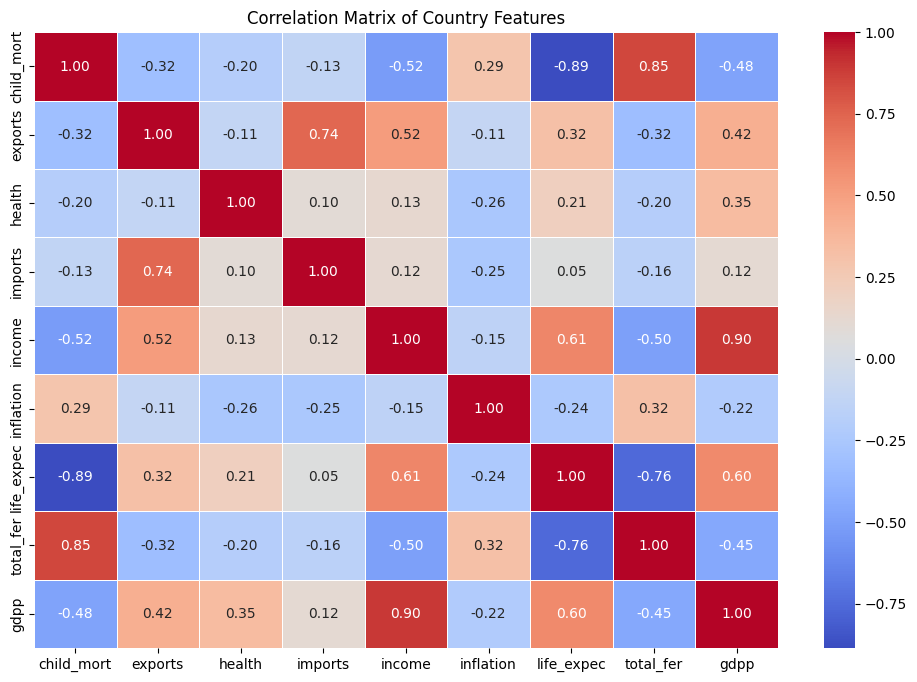

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix of Country Features")
plt.show()

### 11. Dropping the Country Column

The 'country' column contains country names, which are categorical values and do not contribute to numerical distance calculations.

Since K-Means clustering works by calculating distances between data points, only numerical features should be included in the model.

Therefore, the 'country' column is removed before preprocessing and clustering.

In [10]:
X = df.drop('country', axis=1)

print(X.head())

   child_mort  exports  health  imports  income  inflation  life_expec  \
0        90.2     10.0    7.58     44.9    1610       9.44        56.2   
1        16.6     28.0    6.55     48.6    9930       4.49        76.3   
2        27.3     38.4    4.17     31.4   12900      16.10        76.5   
3       119.0     62.3    2.85     42.9    5900      22.40        60.1   
4        10.3     45.5    6.03     58.9   19100       1.44        76.8   

   total_fer   gdpp  
0       5.82    553  
1       1.65   4090  
2       2.89   4460  
3       6.16   3530  
4       2.13  12200  


### 12. Feature Scaling using StandardScaler

K-Means clustering is a distance-based algorithm. Features with larger numerical values can dominate the distance calculations and bias the clustering results.

For example:
- GDP values may range from hundreds to thousands.
- Life expectancy values typically range between 30 and 90.

Without scaling, GDP would have a much larger influence on cluster formation.

`StandardScaler` standardizes each feature using:

z = (x - mean) / standard_deviation

After scaling:
- Mean of each feature becomes approximately 0.
- Standard deviation becomes approximately 1.

This ensures that all features contribute equally to the clustering process.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.29153238 -1.13827979  0.27908825 -0.08245496 -0.8082454   0.15733622
  -1.61909203  1.90288227 -0.67917961]
 [-0.5389489  -0.47965843 -0.09701618  0.07083669 -0.3753689  -0.31234747
   0.64786643 -0.85997281 -0.48562324]
 [-0.27283273 -0.09912164 -0.96607302 -0.64176233 -0.22084447  0.78927429
   0.67042323 -0.0384044  -0.46537561]
 [ 2.00780766  0.77538117 -1.44807093 -0.16531531 -0.58504345  1.38705353
  -1.17923442  2.12815103 -0.51626829]
 [-0.69563412  0.1606679  -0.28689415  0.4975675   0.10173177 -0.60174853
   0.70425843 -0.54194633 -0.04181713]]


### 13. Elbow Method

Before applying K-Means, we need to determine the optimal number of clusters (K).

The Elbow Method evaluates different values of K and computes the Within-Cluster Sum of Squares (WCSS), which measures the compactness of clusters.

- Lower WCSS indicates tighter clusters.
- As K increases, WCSS decreases.
- The optimal K is typically chosen at the "elbow point," where the rate of decrease begins to slow significantly.

This point represents a good balance between cluster quality and model complexity.

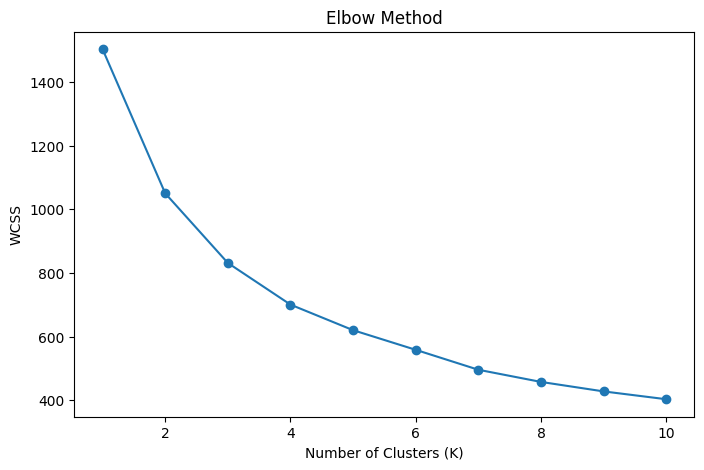

In [12]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### 14. K-Means Clustering

K-Means is an unsupervised machine learning algorithm used to group similar observations into clusters.

The algorithm works as follows:

1. Select K initial centroids.
2. Assign each data point to the nearest centroid.
3. Recalculate the centroid of each cluster.
4. Repeat until cluster assignments no longer change.

In this project, countries are grouped based on socioeconomic indicators such as:
- GDP per capita
- Income
- Child mortality
- Life expectancy
- Imports and exports
- Inflation

Countries within the same cluster are expected to have similar economic and social characteristics.

In [13]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df[['country', 'Cluster']].head())

               country  Cluster
0          Afghanistan        1
1              Albania        2
2              Algeria        2
3               Angola        1
4  Antigua and Barbuda        2


### 15.Cluster Distribution

This step shows the number of countries assigned to each cluster.

It helps evaluate:
- Whether clusters are balanced.
- Whether any cluster contains significantly more countries than others.
- The overall segmentation structure produced by the K-Means algorithm.

In [14]:
print(df['Cluster'].value_counts())

Cluster
2    84
1    47
0    36
Name: count, dtype: int64


### 16. Cluster Label Assignment

K-Means clustering assigns numerical cluster IDs (0, 1, 2, etc.), but these IDs do not have any inherent meaning.

To make the results more interpretable, cluster centers were analyzed based on key socioeconomic indicators such as:

- GDP per capita
- Income
- Life Expectancy
- Child Mortality
- Fertility Rate

Based on these characteristics, descriptive labels were assigned to each cluster:

1. **Developed Countries**
   - High GDP per capita
   - High income levels
   - High life expectancy
   - Low child mortality

2. **Developing Countries**
   - Moderate GDP and income
   - Improving social and economic indicators
   - Moderate life expectancy

3. **Underdeveloped Countries**
   - Low GDP per capita
   - Low income levels
   - High child mortality
   - Low life expectancy

These labels provide a meaningful interpretation of the clusters and help in understanding the socioeconomic status of countries within each group.

In [15]:
cluster_labels = {
    0: "Developing Countries",
    1: "Developed Countries",
    2: "Underdeveloped Countries"
}

df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

df[['country', 'Cluster', 'Cluster_Label']].head()

,country,Cluster,Cluster_Label
0,Afghanistan,1,Developed Countries
1,Albania,2,Underdeveloped Countries
2,Algeria,2,Underdeveloped Countries
3,Angola,1,Developed Countries
4,Antigua and Barbuda,2,Underdeveloped Countries


In [16]:
for label in df['Cluster_Label'].unique():
    print(f"\n{label}")
    print(df[df['Cluster_Label'] == label]['country'].tolist())


Developed Countries
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']

Underdeveloped Countries
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Grena

### 17. Cluster Centers

Cluster centers (centroids) represent the average characteristics of countries within each cluster.

Since the model was trained on standardized data, the centroids are transformed back to their original scale using `inverse_transform()`.

These centroids help interpret each cluster by showing typical values for:
- GDP
- Income
- Life Expectancy
- Child Mortality
- Fertility Rate
- Imports and Exports

The cluster centers provide insight into the socioeconomic profile of each group of countries.

In [17]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

print(cluster_centers)

   child_mort    exports    health    imports        income  inflation  \
0    5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1   92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2   21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

   life_expec  total_fer          gdpp  
0   80.127778   1.752778  42494.444444  
1   59.187234   5.008085   1922.382979  
2   72.814286   2.307500   6486.452381  


### 18. Train-Test Split

The dataset is divided into two parts:

- Training Set (75%)
- Testing Set (25%)

The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

Parameters used:

- `test_size=0.25`
  - Allocates 25% of the data for testing.
  - Remaining 75% is used for training.

- `random_state=42`
  - Ensures reproducible results.

- `stratify=y`
  - Preserves the proportion of each cluster label in both training and testing datasets.

In [18]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop(['country', 'Cluster', 'Cluster_Label'], axis=1)

# Target
y = df['Cluster_Label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (125, 9)
Testing Set Shape: (42, 9)


### 19. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

How it works:

1. Multiple decision trees are created using random subsets of the training data.
2. Each tree makes an independent prediction.
3. The final prediction is determined by majority voting.

Advantages:

- Handles non-linear relationships effectively.
- Reduces overfitting compared to a single decision tree.
- Works well with numerical features.
- Provides feature importance scores.

Parameters:

- `n_estimators=100`
  - Creates 100 decision trees.

- `random_state=42`
  - Ensures reproducibility of results.

In [19]:
## Random Forest Classification
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9761904761904762

Classification Report:
                          precision    recall  f1-score   support

     Developed Countries       1.00      1.00      1.00        12
    Developing Countries       1.00      0.89      0.94         9
Underdeveloped Countries       0.95      1.00      0.98        21

                accuracy                           0.98        42
               macro avg       0.98      0.96      0.97        42
            weighted avg       0.98      0.98      0.98        42


Confusion Matrix:
[[12  0  0]
 [ 0  8  1]
 [ 0  0 21]]


### 20. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting.

Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, where each new tree attempts to correct the errors made by previous trees.

How it works:

1. Train the first decision tree.
2. Calculate prediction errors.
3. Train the next tree to reduce those errors.
4. Repeat the process until the desired number of trees is reached.

Advantages:

- High predictive performance.
- Handles complex patterns effectively.
- Includes regularization to reduce overfitting.
- Efficient and scalable for large datasets.

Parameters:

- `n_estimators=100`
  - Number of boosting trees.

- `max_depth=4`
  - Maximum depth of each tree.

- `learning_rate=0.1`
  - Controls the contribution of each tree.

- `eval_metric='mlogloss'`
  - Evaluation metric for multiclass classification.

In [20]:
## XGBoost requires numerical target values.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

In [21]:
## XGBoost Classification
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

## Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.9761904761904762

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.89      0.94         9
           2       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.96      0.97        42
weighted avg       0.98      0.98      0.98        42



### 22. Model Comparison

Both Random Forest and XGBoost were trained to predict the cluster category of each country.

The models are compared using accuracy on the test dataset.

- Higher accuracy indicates better predictive performance.
- Random Forest provides a strong baseline model.
- XGBoost often achieves higher accuracy due to its boosting mechanism and ability to learn complex patterns.

The comparison helps identify the most effective model for classifying countries into Developed, Developing, and Underdeveloped categories.

In [22]:
rf_accuracy = accuracy_score(y_test, rf_pred)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")
print(f"XGBoost Accuracy       : {xgb_accuracy:.4f}")

Random Forest Accuracy : 0.0000
XGBoost Accuracy       : 0.9762


### 23. Applying DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups observations based on data density.

Unlike K-Means, DBSCAN:
- Does not require specifying the number of clusters beforehand.
- Can identify outliers and noise points.
- Forms clusters based on dense regions of data.

Parameters:

- `eps`
  - Maximum distance between neighboring points.
  - Controls cluster size.

- `min_samples`
  - Minimum number of neighboring points required to form a cluster.

The algorithm assigns:
- Cluster labels (0, 1, 2, ...)
- Noise points labeled as `-1`

In [23]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['DBSCAN_Cluster'] = dbscan_clusters

# View cluster counts
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


### 24. DBSCAN Cluster Analysis

After clustering, the resulting groups are analyzed to understand their socioeconomic characteristics.

Key analysis includes:

- Number of clusters discovered.
- Number of noise points.
- Distribution of countries across clusters.
- Average feature values within each cluster.

The cluster profiles help identify:

- High-income country groups.
- Middle-income country groups.
- Low-income country groups.
- Outlier countries with unique characteristics.

Noise points (`-1`) represent countries that do not belong to any dense cluster.

In [24]:
# Number of clusters (excluding noise)
n_clusters = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)

# Number of noise points
n_noise = list(dbscan_clusters).count(-1)

print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)

# Cluster distribution
print(df['DBSCAN_Cluster'].value_counts())

Number of Clusters: 1
Number of Noise Points: 30
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [25]:
cluster_profile = df.groupby('DBSCAN_Cluster').mean(numeric_only=True)

print(cluster_profile)

                child_mort    exports    health    imports        income  \
DBSCAN_Cluster                                                             
-1               60.203333  56.783333  7.203667  58.390000  26348.566667   
 0               33.467153  37.676635  6.730730  44.372014  15129.240876   

                inflation  life_expec  total_fer          gdpp   Cluster  
DBSCAN_Cluster                                                            
-1              14.349800   66.320000   3.544333  19705.700000  0.866667  
 0               6.343591   71.483212   2.817372  11487.905109  1.379562  


### 25. Hyperparameter Tuning

DBSCAN performance depends heavily on two parameters:

1. `eps`
2. `min_samples`

The tuning process involves evaluating multiple combinations of these parameters and observing:

- Number of clusters formed.
- Number of noise points detected.
- Cluster quality.

Goal:

- Avoid too many tiny clusters.
- Avoid labeling most countries as noise.
- Obtain meaningful and interpretable country groups.

Hyperparameter tuning helps identify values that best represent the underlying structure of the dataset.

In [26]:
## Experimenting with different eps values
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]

for eps in eps_values:
    
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = model.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)
    
    print(
        f"eps={eps} | Clusters={n_clusters} | Noise={noise_points}"
    )


eps=0.5 | Clusters=0 | Noise=167
eps=1.0 | Clusters=3 | Noise=94
eps=1.5 | Clusters=1 | Noise=30
eps=2.0 | Clusters=1 | Noise=15
eps=2.5 | Clusters=1 | Noise=6


In [27]:
## Tune min_samples parameter

min_samples_values = [3, 5, 7, 10]

for ms in min_samples_values:
    
    model = DBSCAN(
        eps=1.5,
        min_samples=ms
    )
    
    labels = model.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)
    
    print(
        f"min_samples={ms} | Clusters={n_clusters} | Noise={noise_points}"
    )

min_samples=3 | Clusters=2 | Noise=25
min_samples=5 | Clusters=1 | Noise=30
min_samples=7 | Clusters=1 | Noise=31
min_samples=10 | Clusters=1 | Noise=38


### 26. Parameter Optimization

Parameter optimization aims to identify the best combination of DBSCAN parameters.

The Silhouette Score is used as an evaluation metric.

Silhouette Score Range:

- +1 : Well-separated clusters
- 0 : Overlapping clusters
- -1 : Poor clustering

The optimization process:

1. Test multiple combinations of `eps` and `min_samples`.
2. Compute the Silhouette Score.
3. Select the parameter combination with the highest score.

The optimal parameters provide clusters that are:
- Compact
- Well-separated
- More meaningful for interpretation

In [28]:
from sklearn.metrics import silhouette_score
import numpy as np

best_score = -1
best_eps = None
best_min_samples = None

for eps in np.arange(0.5, 3.0, 0.25):
    
    for ms in range(3, 11):
        
        model = DBSCAN(
            eps=eps,
            min_samples=ms
        )
        
        labels = model.fit_predict(X_scaled)
        
        unique_labels = set(labels)
        
        # Need at least 2 clusters
        if len(unique_labels) > 2:
            
            try:
                score = silhouette_score(
                    X_scaled,
                    labels
                )
                
                if score > best_score:
                    best_score = score
                    best_eps = eps
                    best_min_samples = ms
                    
            except:
                pass

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Best Silhouette Score:", best_score)

Best eps: 1.75
Best min_samples: 3
Best Silhouette Score: 0.1577018721741829


### 27. Final DBSCAN Clustering

After identifying the optimal hyperparameters, DBSCAN is trained using the best parameter combination.

The final clustering results represent the most suitable grouping of countries based on socioeconomic indicators.

The resulting clusters are analyzed through:

- Cluster sizes.
- Country membership.
- Cluster centroids (average feature values).
- Noise points.

These clusters can be interpreted as different levels of economic and social development, while noise points highlight countries with unique characteristics that do not fit naturally into any major group.

The final DBSCAN model provides a density-based perspective of country segmentation and serves as a useful comparison with K-Means clustering results.

In [29]:
final_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

final_clusters = final_dbscan.fit_predict(X_scaled)

df['Final_DBSCAN_Cluster'] = final_clusters

print(df['Final_DBSCAN_Cluster'].value_counts())

Final_DBSCAN_Cluster
 0    145
-1     19
 1      3
Name: count, dtype: int64


In [30]:
for cluster in sorted(df['Final_DBSCAN_Cluster'].unique()):
    
    print(f"\nCluster {cluster}")
    
    countries = df[
        df['Final_DBSCAN_Cluster'] == cluster
    ]['country']
    
    print(countries.tolist())


Cluster -1
['Brunei', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Kuwait', 'Lesotho', 'Luxembourg', 'Malta', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Seychelles', 'Sierra Leone', 'Singapore', 'Timor-Leste', 'United States', 'Venezuela']

Cluster 0
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Estonia', 'Fiji', 'Finland', 'France', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala',

In [31]:
final_profile = df.groupby(
    'Final_DBSCAN_Cluster'
).mean(numeric_only=True)

print(final_profile)

                      child_mort    exports     health    imports  \
Final_DBSCAN_Cluster                                                
-1                     53.142105  67.005263   6.554211  60.878947   
 0                     35.788966  38.180683   6.733724  44.279075   
 1                     64.000000  18.633333  12.433333  84.500000   

                            income  inflation  life_expec  total_fer  \
Final_DBSCAN_Cluster                                                   
-1                    36610.526316  18.412842   68.589474   3.134737   
 0                    14908.917241   6.475393   70.984138   2.899517   
 1                     1923.333333   3.596667   62.300000   4.106667   

                              gdpp   Cluster  DBSCAN_Cluster  
Final_DBSCAN_Cluster                                          
-1                    27194.789474  0.736842       -1.000000  
 0                    11335.420690  1.358621       -0.055172  
 1                     1559.000000  1.333

### 28. Feature Importance Analysis

Feature importance measures the contribution of each feature to the prediction made by the Random Forest model.

Random Forest calculates feature importance based on how much each feature reduces impurity across all decision trees.

Higher importance values indicate that a feature plays a more significant role in distinguishing between country clusters.

This analysis helps identify the most influential socioeconomic indicators affecting country development classification.

In [32]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
0  child_mort    0.277494
8        gdpp    0.210954
7   total_fer    0.158430
6  life_expec    0.153967
4      income    0.144148
2      health    0.024132
5   inflation    0.013489
3     imports    0.009809
1     exports    0.007576


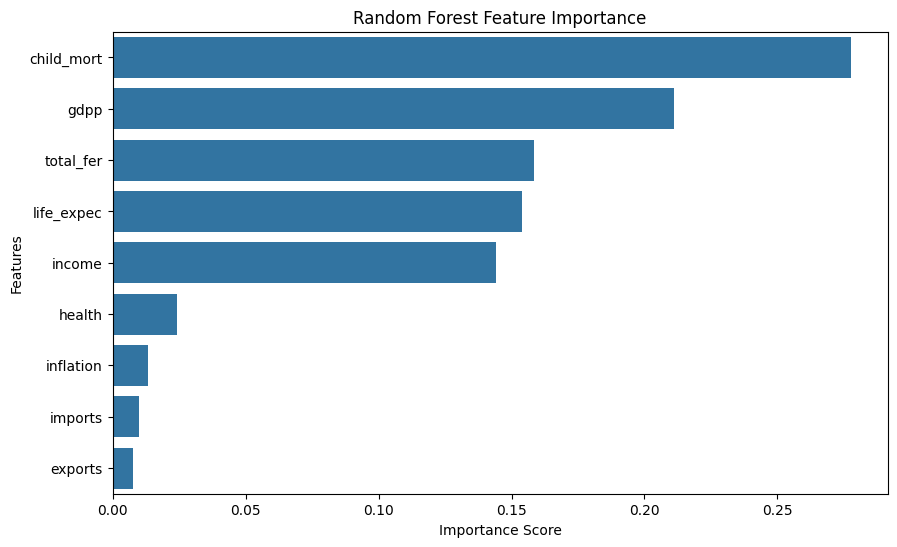

In [33]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

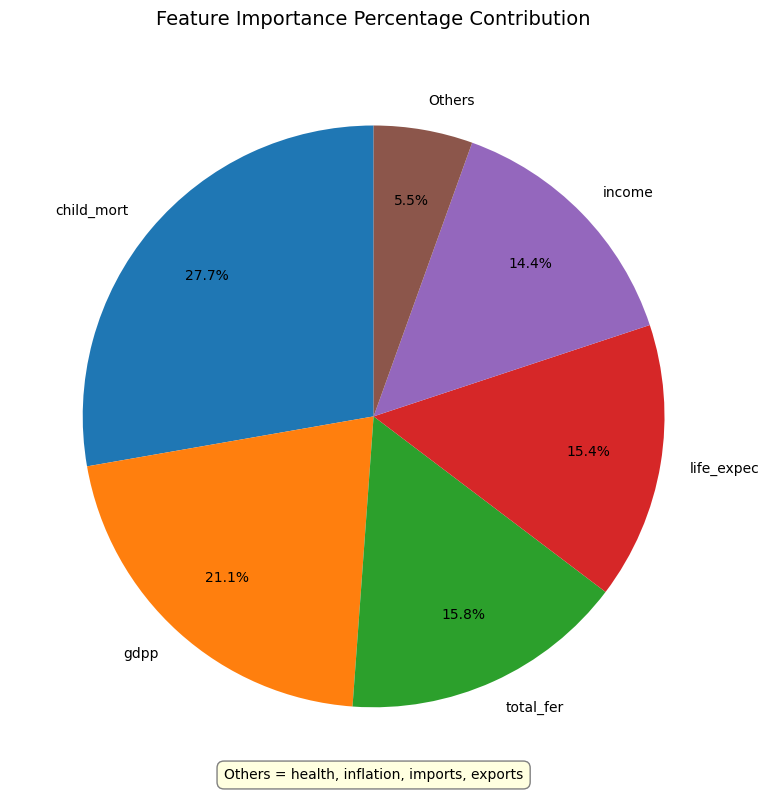

In [34]:
# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Calculate percentage contribution
feature_importance['Percentage'] = (
    feature_importance['Importance']
    / feature_importance['Importance'].sum()
) * 100

# Threshold for grouping small features
threshold = 3

# Major features
major = feature_importance[
    feature_importance['Percentage'] >= threshold
]

# Features to combine into "Others"
others = feature_importance[
    feature_importance['Percentage'] < threshold
]

others_percentage = others['Percentage'].sum()
others_features = others['Feature'].tolist()

# Create plotting dataframe
plot_df = major[['Feature', 'Percentage']].copy()

# Add Others row if needed
if others_percentage > 0:
    plot_df.loc[len(plot_df)] = [
        'Others',
        others_percentage
    ]

# Plot pie chart
plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    plot_df['Percentage'],
    labels=plot_df['Feature'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

# Add note box describing Others
if len(others_features) > 0:
    plt.figtext(
        0.5,
        0.02,
        "Others = " + ", ".join(others_features),
        ha='center',
        fontsize=10,
        bbox=dict(
            facecolor='lightyellow',
            edgecolor='gray',
            boxstyle='round,pad=0.5'
        )
    )

plt.title(
    "Feature Importance Percentage Contribution",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()


### Interpretation of Results

The feature importance analysis revealed that GDP per capita and income are the strongest predictors of country development status.

Features such as child mortality, life expectancy, and fertility rate also contribute significantly because they reflect the overall social and economic well-being of a country.

Imports and exports may have lower importance because they do not directly capture the standard of living or development level compared to GDP and income indicators.

These findings align with economic theory, where wealth, healthcare outcomes, and demographic indicators are key determinants of a country's development status.